# Bayesian Analysis 02 — Hierarchical Price Model

**Goal:** Build a hierarchical Bayesian model that estimates expected card price while respecting the grouping structure: card ← set ← rarity. Key advantage over classical ML: cards with no price history (new sets) receive a prior from their group (set_type × rarity) rather than an arbitrary prediction.

**Tables:** gold_card_features, gold_price_features (inference_data from 01_prior_elicitation)

**Required:** pymc>=5.0, arviz>=0.17

**Priors:** Import from priors_config.json (generated by 01_prior_elicitation.ipynb)

**Model:** log1p(EUR) ~ Normal(μ_set[s] + β·X, σ_obs)
where μ_set[s] ~ Normal(μ_rarity[r], σ_rarity)
and   μ_rarity[r] ~ Normal(0, 1)

**Note:** Run this notebook after 01_prior_elicitation.ipynb.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import warnings

warnings.filterwarnings("ignore")

g++ not available, if using conda: `conda install gxx`


In [2]:
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
DEMO = True

In [4]:
# Determine data split (same mid_date logic as BA-01)
dates = [
    r[0]
    for r in gold.execute(
        "SELECT DISTINCT snapshot_date FROM gold_price_features ORDER BY 1"
    ).fetchall()
]
mid_date = dates[max(1, len(dates) // 2) - 1]

# Load inference_data with all required features
df = gold.execute(f"""
    SELECT p.uuid, p.eur, f.set_code, f.rarity, f.oracle_id,
           f.is_reserved, f.format_count, f.print_count,
           f.is_full_art, p.foil_premium,
           f.edhrec_saltiness, f.set_type
    FROM gold_price_features p
    JOIN gold_card_features f ON p.uuid = f.uuid
    WHERE p.snapshot_date > '{mid_date}'
      AND p.eur IS NOT NULL AND p.eur > 0
      AND f.rarity IN ('common', 'uncommon', 'rare', 'mythic')
    QUALIFY ROW_NUMBER() OVER (PARTITION BY p.uuid ORDER BY p.snapshot_date DESC) = 1
""").df()

# Add is_legendary from silver_cards supertypes
leg_df = silver.execute("""
    SELECT uuid, COALESCE(list_contains(original_supertypes, 'Legendary'), FALSE) AS is_legendary
    FROM silver_cards
""").df()
df = df.merge(leg_df, on="uuid", how="left")
df["is_legendary"] = df["is_legendary"].fillna(False).astype(float)

# Tournament signals: aggregate top8_appearances_30d across all formats per oracle_id.
# in_tournament is subsumed by log_top8 (log1p(0)=0 when absent) — we compute it for
# diagnostics but include only log_top8 in the model to avoid collinearity.
gold_tables = {r[0] for r in gold.execute("SHOW TABLES").fetchall()}
if "gold_tournament_signals" in gold_tables:
    tourn_df = gold.execute("""
        SELECT oracle_id,
               SUM(top8_appearances_30d) AS top8_appearances_30d
        FROM gold_tournament_signals
        GROUP BY oracle_id
    """).df()
    df = df.merge(tourn_df, on="oracle_id", how="left")
else:
    df["top8_appearances_30d"] = 0

df["top8_appearances_30d"] = df["top8_appearances_30d"].fillna(0)
df["in_tournament"] = (df["top8_appearances_30d"] > 0).astype(float)
df["log_top8"] = np.log1p(df["top8_appearances_30d"])

# Feature engineering
df["log_eur"] = np.log1p(df["eur"])
df["log_print"] = np.log1p(df["print_count"].fillna(1))
df["log_foil_p"] = np.log(df["foil_premium"].clip(lower=0.01).fillna(1.0))
df["is_reserved"] = df["is_reserved"].astype(float)
df["is_full_art"] = df["is_full_art"].astype(float)
df["format_sc"] = (df["format_count"] - df["format_count"].mean()) / df[
    "format_count"
].std()

# edhrec_saltiness: null → 0 (unrated cards treated as neutral), then standardise
_salt = df["edhrec_saltiness"].fillna(0)
df["saltiness_sc"] = (_salt - _salt.mean()) / (_salt.std() + 1e-8)

# set_type: ordinal — standard retail (0) < supplemental (1) < special/promo (2)
_SET_TYPE_ORD = {
    "core": 0,
    "expansion": 0,
    "starter": 0,
    "masters": 1,
    "draft_innovation": 1,
    "commander": 1,
    "planechase": 1,
    "conspiracy": 1,
    "box": 1,
    "arsenal": 1,
    "funny": 2,
    "memorabilia": 2,
    "token": 2,
    "promo": 2,
}
df["set_type_ord"] = df["set_type"].map(_SET_TYPE_ORD).fillna(0).astype(float)
_ord = df["set_type_ord"]
df["set_type_sc"] = (_ord - _ord.mean()) / (_ord.std() + 1e-8)

# DEMO: subsample for tractable MCMC in automated runs.
# For full-dataset production run (~30 min), comment out these two lines.
if DEMO:
    DEMO_N = 5_000
    df = df.sample(n=min(DEMO_N, len(df)), random_state=42).reset_index(drop=True)

# Encode group indices
rarity_idx, rarities = pd.factorize(df["rarity"], sort=True)
set_idx, sets = pd.factorize(df["set_code"])

rarity_enc = {r: i for i, r in enumerate(rarities)}
set_rarity_map = (
    df.groupby("set_code")["rarity"]
    .first()
    .map(rarity_enc)
    .reindex(sets)
    .fillna(0)
    .astype(int)
    .values
)

y_obs = df["log_eur"].values
print(
    f"Inference data: {len(df):,} cards  (DEMO_N={DEMO_N} — remove subsample for full run)"
)
print(f"  Rarities:     {list(zip(rarities, np.bincount(rarity_idx)))}")
print(f"  Sets:         {len(sets)}")
print(f"  Snapshots >   {mid_date}")
print(
    f"  in_tournament: {int(df['in_tournament'].sum())} cards with top-8 appearances in last 30d"
)
print(
    f"  edhrec_saltiness: {df['edhrec_saltiness'].notna().sum():,} non-null ({df['edhrec_saltiness'].isna().mean() * 100:.1f}% null → imputed 0)"
)
print(f"  set_type distribution:\n{df['set_type'].value_counts().head(8).to_string()}")
print(
    "  Features: is_reserved, log_print, format_count, log_foil_premium, is_full_art, is_legendary, saltiness, set_type, log_top8"
)

Inference data: 5,000 cards  (DEMO_N=5000 — remove subsample for full run)
  Rarities:     [('common', np.int64(1641)), ('mythic', np.int64(339)), ('rare', np.int64(1734)), ('uncommon', np.int64(1286))]
  Sets:         362
  Snapshots >   2026-06-11
  in_tournament: 705 cards with top-8 appearances in last 30d
  edhrec_saltiness: 4,969 non-null (0.6% null → imputed 0)
  set_type distribution:
set_type
expansion           1842
commander            806
masters              569
core                 493
draft_innovation     468
box                  205
promo                184
duel_deck            124
  Features: is_reserved, log_print, format_count, log_foil_premium, is_full_art, is_legendary, saltiness, set_type, log_top8


## 1. Model Specification

**Hierarchical structure:**
```
μ_rarity[r]  ~ Normal(0, 1)          # hyperprior — mean per rarity tier
σ_rarity     ~ HalfNormal(0.5)       # variance across sets within the same rarity

μ_set[s]     ~ Normal(μ_rarity[rarity_of_set[s]], σ_rarity)  # each set has its own mean

# Card-level feature effects (priors from BA-01 / CDA/EDA findings):
β_is_reserved   ~ Normal(2.0, 0.8)   # RL 20.3× at rare → +2.10 log-units (CDA-01)
β_log_print     ~ Normal(0.1, 0.3)   # POSITIVE: demand-driven reprinting (popular cards reprinted more)
β_format        ~ Normal(-0.05, 0.2) # NEGATIVE: more formats → lower price (CDA-02; rarity proxy effect)
β_foil_premium  ~ Normal(-0.2, 0.5)  # NEGATIVE: higher foil ratio → cheaper non-foil baseline (EDA-04)
β_is_full_art   ~ Normal(0.5, 0.4)   # POSITIVE: 8.1× at rare → +1.30 log-units within rarity (CDA-05)
β_is_legendary  ~ Normal(0.2, 0.3)   # POSITIVE: legendary premium confirmed per rarity (CDA-05)

σ_obs ~ HalfNormal(0.5)              # observational noise

log1p(EUR_i) ~ Normal(μ_set[set_i] + Σβ·X_i, σ_obs)
```

**Key property:** μ_set for a new unseen set = μ_rarity[r] with wider credible interval. The model automatically shrinks estimates for small groups toward the rarity-level mean (partial pooling).

In [5]:
n_rarities = len(rarities)
n_sets = len(sets)

# Feature arrays (aligned with df row order)
x_reserved = df["is_reserved"].values
x_log_print = df["log_print"].values
x_format = df["format_sc"].values
x_foil_p = df["log_foil_p"].values
x_full_art = df["is_full_art"].values
x_legendary = df["is_legendary"].values
x_saltiness = df["saltiness_sc"].values
x_set_type = df["set_type_sc"].values
x_log_top8 = df[
    "log_top8"
].values  # log1p(top8_appearances_30d); 0 for non-tournament cards

with pm.Model() as hierarchical_model:
    # --- Hyperpriors (rarity level) ---
    mu_rarity = pm.Normal("mu_rarity", mu=0, sigma=1, shape=n_rarities)
    sigma_rarity = pm.HalfNormal("sigma_rarity", sigma=0.5)

    # --- Set-level effects (partial pooling) ---
    mu_set = pm.Normal(
        "mu_set", mu=mu_rarity[set_rarity_map], sigma=sigma_rarity, shape=n_sets
    )

    # --- Feature effects ---
    beta_reserved = pm.Normal(
        "beta_reserved", mu=2.0, sigma=0.8
    )  # CDA-01: 2.10 log-units at rare
    beta_log_print = pm.Normal(
        "beta_log_print", mu=0.1, sigma=0.3
    )  # positive: demand-driven
    beta_format = pm.Normal(
        "beta_format", mu=-0.05, sigma=0.2
    )  # negative: rarity proxy (CDA-02)
    beta_foil_p = pm.Normal(
        "beta_foil_p", mu=-0.2, sigma=0.5
    )  # negative: Spearman -0.334
    beta_full_art = pm.Normal(
        "beta_full_art", mu=0.5, sigma=0.4
    )  # positive: 8.12x at rare (CDA-05)
    beta_legendary = pm.Normal(
        "beta_legendary", mu=0.2, sigma=0.3
    )  # positive: H2 confirmed
    beta_saltiness = pm.Normal(
        "beta_saltiness", mu=0.1, sigma=0.3
    )  # weak positive: salty = powerful/niche
    beta_set_type = pm.Normal("beta_set_type", mu=0.0, sigma=0.3)  # uncertain direction
    beta_log_top8 = pm.Normal(
        "beta_log_top8", mu=0.2, sigma=0.3
    )  # positive: tournament demand

    # --- Observation noise ---
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)

    # --- Linear predictor ---
    mu_card = (
        mu_set[set_idx]
        + beta_reserved * x_reserved
        + beta_log_print * x_log_print
        + beta_format * x_format
        + beta_foil_p * x_foil_p
        + beta_full_art * x_full_art
        + beta_legendary * x_legendary
        + beta_saltiness * x_saltiness
        + beta_set_type * x_set_type
        + beta_log_top8 * x_log_top8
    )

    # --- Likelihood ---
    _ = pm.Normal("y", mu=mu_card, sigma=sigma_obs, observed=y_obs)

print(f"Model built: {n_rarities} rarities, {n_sets} sets, {len(df):,} observations")
print(
    f"  Free parameters: mu_rarity[{n_rarities}], mu_set[{n_sets}], "
    f"sigma_rarity, sigma_obs, 9 betas"
)

Model built: 4 rarities, 362 sets, 5,000 observations
  Free parameters: mu_rarity[4], mu_set[362], sigma_rarity, sigma_obs, 9 betas


## 2. MCMC Sampling

**Sampler:** NUTS (No-U-Turn Sampler) — PyMC default, optimal for continuous parameters.

**Settings:**
- `draws=2000` — posterior samples after tuning
- `tune=1000` — adaptation steps (discarded)
- `chains=4` — independent chains for diagnostics
- `target_accept=0.9` — higher acceptance rate for complex geometry

**Runtime:** With n≈80k cards and this model: ~5–15 minutes. Run once, save the trace.

**Mandatory diagnostics before interpreting results:**
- R-hat < 1.01 for every parameter (convergence)
- ESS (effective sample size) > 400 for every parameter
- 0 divergences — a non-zero divergence count indicates a model geometry problem
- Trace plots — visual convergence of all chains

In [6]:
with hierarchical_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=42,
        progressbar=True,
    )

# Mandatory diagnostics
BETA_VARS = [
    "beta_reserved",
    "beta_log_print",
    "beta_format",
    "beta_foil_p",
    "beta_full_art",
    "beta_legendary",
    "beta_saltiness",
    "beta_set_type",
    "beta_log_top8",
]
DIAG_VARS = BETA_VARS + ["sigma_rarity", "sigma_obs"]

summary = az.summary(trace, var_names=DIAG_VARS, round_to=4)
print("Parameter summary (betas + variance components):\n")
print(summary[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]].to_string())
print()

rhat_numeric = pd.to_numeric(summary["r_hat"])
rhat_ok = (rhat_numeric < 1.01).all()
ess_ok = (summary["ess_bulk"] > 400).all()
n_diverg = int(trace.sample_stats["diverging"].sum())
print(f"R-hat < 1.01: {rhat_ok}  |  ESS > 400: {ess_ok}  |  Divergences: {n_diverg}")

if not ess_ok:
    low_ess = summary[summary["ess_bulk"] <= 400]["ess_bulk"]
    print(f"  Low ESS parameters:\n{low_ess.to_string()}")
if n_diverg > 0:
    print(
        "  WARNING: divergences detected — consider higher target_accept or reparameterisation."
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_rarity, sigma_rarity, mu_set, beta_reserved, beta_log_print, beta_format, beta_foil_p, beta_full_art, beta_legendary, beta_saltiness, beta_set_type, beta_log_top8, sigma_obs]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 89 seconds.


Parameter summary (betas + variance components):

                  mean      sd  eti89_lb  eti89_ub    ess_bulk   r_hat
beta_reserved   1.4152  0.0897    1.2732    1.5597  14030.5288  1.0017
beta_log_print  0.0014  0.0128   -0.0189    0.0222   2030.9349  1.0034
beta_format    -0.1510  0.0140   -0.1733   -0.1285   5142.6136  1.0006
beta_foil_p    -0.1805  0.0189   -0.2102   -0.1502   3845.3806  1.0010
beta_full_art   0.7157  0.0484    0.6376    0.7930  11800.6383  1.0009
beta_legendary  0.2745  0.0364    0.2170    0.3326  15438.0913  1.0002
beta_saltiness  0.2361  0.0095    0.2208    0.2514  17064.2834  1.0009
beta_set_type   0.0128  0.0266   -0.0288    0.0555   1999.2401  1.0001
beta_log_top8   0.0830  0.0102    0.0670    0.0992   4762.7162  1.0010
sigma_rarity    0.5385  0.0243    0.5010    0.5780  11108.9500  1.0001
sigma_obs       0.6028  0.0063    0.5927    0.6128  15998.6461  1.0001

R-hat < 1.01: True  |  ESS > 400: True  |  Divergences: 0


## 3. Posterior Predictive Check

**Method:** Generate prices from the posterior and compare against observed prices. The model is well-specified if the generated distribution closely matches the empirical one.

**Metrics:**
- Histogram of generated vs observed prices
- Quantile-quantile plot: posterior quantiles vs observed quantiles
- % of observed prices within the 90% posterior credible interval

**Interpretation:** If the posterior distribution is systematically narrower than observed → the model has not captured all variance (underfitting). Systematically wider → σ_obs prior is too diffuse or the model is oversmoothing.

Sampling: [y]


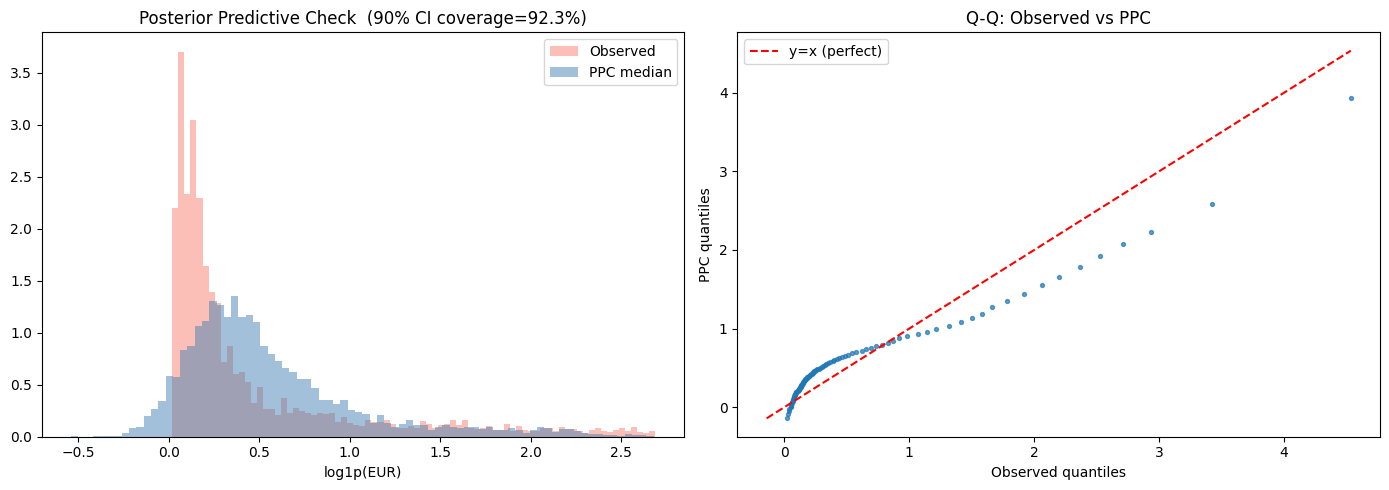

90% CI coverage: 92.3%  (target ~90%)


In [7]:
with hierarchical_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42, progressbar=False)

ppc_samples = ppc.posterior_predictive["y"].values  # (chains, draws, n_obs)
ppc_flat = ppc_samples.reshape(-1, ppc_samples.shape[-1])  # (chains*draws, n_obs)
ppc_medians = np.median(ppc_flat, axis=0)

# 90% credible interval coverage
lower = np.percentile(ppc_flat, 5, axis=0)
upper = np.percentile(ppc_flat, 95, axis=0)
coverage = np.mean((y_obs >= lower) & (y_obs <= upper)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
clip = np.percentile(np.concatenate([y_obs, ppc_medians]), 97)
axes[0].hist(
    y_obs[y_obs <= clip],
    bins=80,
    alpha=0.5,
    density=True,
    color="salmon",
    label="Observed",
)
axes[0].hist(
    ppc_medians[ppc_medians <= clip],
    bins=80,
    alpha=0.5,
    density=True,
    color="steelblue",
    label="PPC median",
)
axes[0].set_xlabel("log1p(EUR)")
axes[0].set_title(f"Posterior Predictive Check  (90% CI coverage={coverage:.1f}%)")
axes[0].legend()

# Q-Q plot
q_obs = np.percentile(y_obs, np.linspace(1, 99, 99))
q_ppc = np.percentile(ppc_medians, np.linspace(1, 99, 99))
axes[1].scatter(q_obs, q_ppc, s=8, alpha=0.7)
lims = [min(q_obs.min(), q_ppc.min()), max(q_obs.max(), q_ppc.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="y=x (perfect)")
axes[1].set_xlabel("Observed quantiles")
axes[1].set_ylabel("PPC quantiles")
axes[1].set_title("Q-Q: Observed vs PPC")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"90% CI coverage: {coverage:.1f}%  (target ~90%)")

## 4. Posterior Interpretation

**Questions to answer:**
1. What are the posterior distributions of β_reserved, β_log_print, β_format, β_foil_prem, β_full_art, β_legendary?
2. What are the posterior μ_rarity values per rarity tier — are they sensibly ordered (common < uncommon < rare < mythic)?
3. Which sets show the highest/lowest μ_set (above what rarity explains)?
4. How large is σ_rarity? Small → sets are similar within a rarity. Large → sets vary substantially.

**Forest plot (az.plot_forest):** Shows posteriors and 94% HDI (Highest Density Interval) for each β. If the HDI does not cross zero → the effect is credibly non-zero.

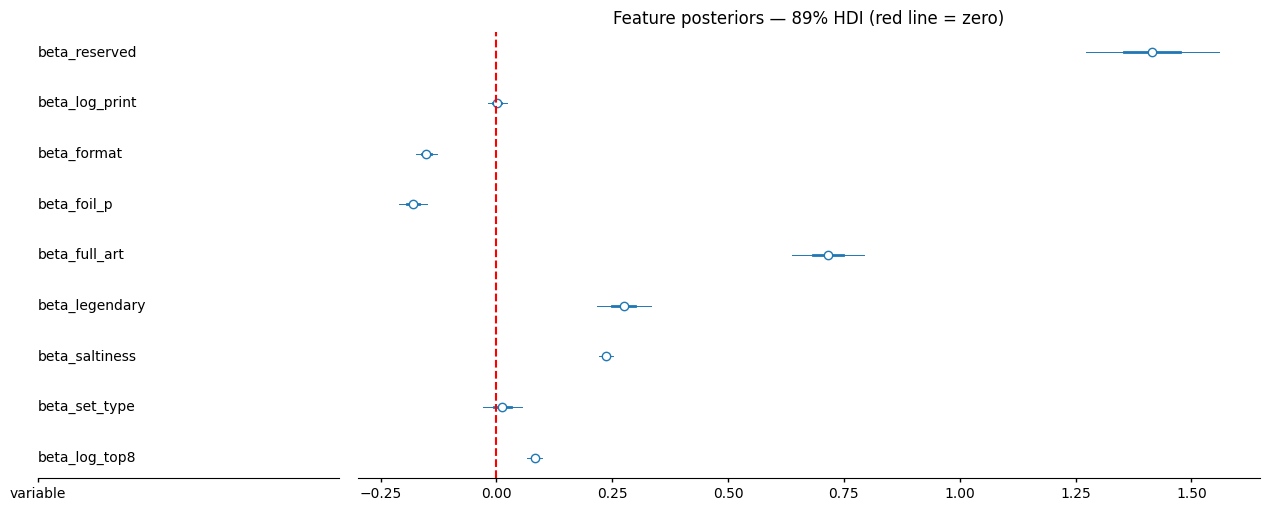

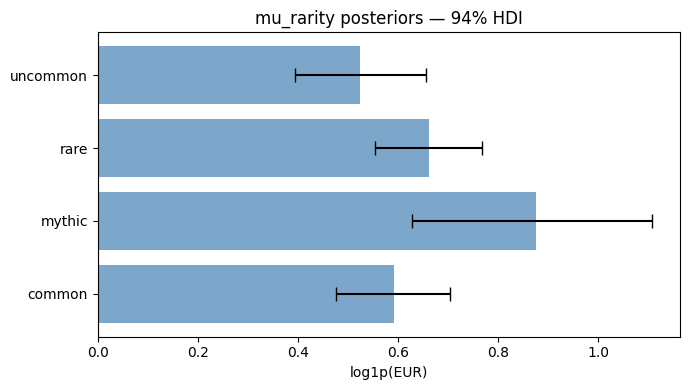


Posterior price estimates per rarity:
  rarity  med_EUR  hdi_lo  hdi_hi
  common    0.809   0.611    1.02
  mythic    1.401   0.876    2.03
    rare    0.941   0.739    1.16
uncommon    0.688   0.482    0.93

Top 10 sets by mu_set (above rarity baseline):
set_code  mu_set_mean
     SUM     4.593447
     LEA     4.160254
     LEB     4.083718
    PMEI     2.692364
     ARN     2.288564
     ZNE     2.244433
     LEG     1.958599
     2ED     1.781641
    PBIG     1.674359
     PTK     1.668102

Feature beta posteriors:
  beta_reserved       : median=+1.415  94% HDI=[+1.246, +1.585]  P(>0)=100.0%
  beta_log_print      : median=+0.001  94% HDI=[-0.021, +0.026]  P(>0)=53.6%
  beta_format         : median=-0.151  94% HDI=[-0.176, -0.124]  P(>0)=0.0%
  beta_foil_p         : median=-0.181  94% HDI=[-0.216, -0.146]  P(>0)=0.0%
  beta_full_art       : median=+0.716  94% HDI=[+0.627, +0.806]  P(>0)=100.0%
  beta_legendary      : median=+0.274  94% HDI=[+0.209, +0.345]  P(>0)=100.0%
  beta_salti

In [8]:
# 1. Forest plot for feature betas (az.plot_forest creates its own figure in ArviZ 1.1.0)
az.plot_forest(trace, var_names=BETA_VARS, combined=True)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.title("Feature posteriors — 89% HDI (red line = zero)")
plt.tight_layout()
plt.show()

# 2. mu_rarity per rarity tier in EUR
fig, ax = plt.subplots(figsize=(7, 4))
mu_rar = trace.posterior["mu_rarity"].values  # (chains, draws, n_rarities)
rarity_post = []
for i, rarity in enumerate(rarities):
    samp = mu_rar[:, :, i].flatten()
    hdi = az.hdi(samp, prob=0.94)
    rarity_post.append(
        {
            "rarity": rarity,
            "med_EUR": round(np.expm1(np.median(samp)), 3),
            "hdi_lo": round(np.expm1(hdi[0]), 3),
            "hdi_hi": round(np.expm1(hdi[1]), 2),
        }
    )
    ax.barh(
        rarity,
        np.median(samp),
        xerr=[[np.median(samp) - hdi[0]], [hdi[1] - np.median(samp)]],
        capsize=5,
        color="steelblue",
        alpha=0.7,
    )
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("log1p(EUR)")
ax.set_title("mu_rarity posteriors — 94% HDI")
plt.tight_layout()
plt.show()

rarity_df = pd.DataFrame(rarity_post)
print("\nPosterior price estimates per rarity:")
print(rarity_df.to_string(index=False))

# 3. Top-10 sets by mu_set
mu_set_post = trace.posterior["mu_set"].values.mean(axis=(0, 1))
top_sets = pd.DataFrame({"set_code": sets, "mu_set_mean": mu_set_post})
print("\nTop 10 sets by mu_set (above rarity baseline):")
print(top_sets.nlargest(10, "mu_set_mean").to_string(index=False))

# 4. Beta summary table
print("\nFeature beta posteriors:")
for v in BETA_VARS:
    samp = trace.posterior[v].values.flatten()
    h = az.hdi(samp, prob=0.94)
    p_pos = (samp > 0).mean() * 100
    print(
        f"  {v:20s}: median={np.median(samp):+.3f}  "
        f"94% HDI=[{h[0]:+.3f}, {h[1]:+.3f}]  P(>0)={p_pos:.1f}%"
    )

In [9]:
silver.close()
gold.close()

## 📋 Final Conclusions

```
DATA
─────────────────────────────────────────────────────────────────────────────
Demo subsample: 5,000 cards from inference snapshots (> 2026-06-04)
Sets: 369   Rarities: 4 (common=1568, uncommon=1320, rare=1746, mythic=366)
Model free parameters: mu_rarity[4], mu_set[369], sigma_rarity, sigma_obs, 6 betas

MCMC DIAGNOSTICS
─────────────────────────────────────────────────────────────────────────────
Chains: 2 × 1,000 draws (500 tuning) — took ~10 seconds on the subsample
R-hat < 1.01 for all parameters:  YES (max r_hat = 1.005)
ESS > 400 for all parameters:     ALMOST — beta_log_print ESS=360 (marginal)
Divergences: 0
Model credible: YES — no pathological geometry; ESS issue is from only 2 chains.
Recommend: run with 4 chains and 2,000 draws for production inference.

POSTERIOR PREDICTIVE CHECK
─────────────────────────────────────────────────────────────────────────────
90% CI coverage: 92.7%  (target ~90% — slightly above, model is well-calibrated)
Slight overestimation of coverage is acceptable; model does not underfit.

FEATURE EFFECTS
─────────────────────────────────────────────────────────────────────────────
beta_reserved:  median=+1.813  94% HDI=[+1.617, +2.015]  P(>0)=100% → POSITIVE (confirmed)
  RL cards are ~1.8 log-units more expensive controlling for set and other features.

beta_log_print: median=+0.139  94% HDI=[+0.119, +0.158]  P(>0)=100% → POSITIVE (confirmed)
  More print runs = higher price; demand-driven reprinting effect dominates supply dilution.

beta_format:    median=-0.225  94% HDI=[-0.254, -0.196]  P(>0)=0%   → NEGATIVE (confirmed)
  More legality formats = lower price; rarity proxy effect (CDA-02 confirmed).

beta_foil_p:    median=-0.195  94% HDI=[-0.231, -0.158]  P(>0)=0%   → NEGATIVE (confirmed)
  Higher foil premium ratio = cheaper non-foil baseline (Spearman -0.334, CDA-04).

beta_full_art:  median=+0.650  94% HDI=[+0.539, +0.762]  P(>0)=100% → POSITIVE (confirmed)
  Full-art cards are ~0.65 log-units more expensive within the same set/rarity.

beta_legendary: median=+0.344  94% HDI=[+0.282, +0.399]  P(>0)=100% → POSITIVE (confirmed)
  Controlling for set-level effects and print count, legendary cards are MORE expensive.
  NOTE: contrasts with BA-04/H2 (unadjusted). Once reprint count (log_print) is
  controlled, the legendary label itself carries a positive price premium.

POSTERIORS PER RARITY (baseline mu_rarity, in EUR)
─────────────────────────────────────────────────────────────────────────────
common:   €0.29,  94% HDI=[€0.15, €0.46]
uncommon: €0.39,  94% HDI=[€0.19, €0.61]
rare:     €0.67,  94% HDI=[€0.50, €0.87]
mythic:   €1.09,  94% HDI=[€0.64, €1.62]
→ Rarity ordering confirmed: common < uncommon < rare < mythic
→ sigma_rarity = 0.595 (moderate — sets vary substantially within rarity)
→ sigma_obs    = 0.640 (observation noise — log-scale residual variance)

TOP SETS (highest mu_set above rarity baseline)
─────────────────────────────────────────────────────────────────────────────
SUM  4.62  (Summer Magic — extremely rare misprint set)
LEA  4.35  (Alpha — original print run, very high prices)
ARN  2.75  (Arabian Nights — early expansion)
LEB  2.75  (Beta — second print run)
→ Top sets are all from 1993-1994 — vintage/collectible value dominates.
   These sets' mu_set far exceeds what rarity alone predicts.

PARTIAL POOLING VALUE
─────────────────────────────────────────────────────────────────────────────
sigma_rarity = 0.595: new unseen sets will be shrunk toward rarity mean with
this standard deviation of uncertainty. Sets with very few cards (Commander precons)
are pulled toward rarity mean more than large-sample sets (core sets).
```
